In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path(".").resolve()))
from log_parser import CHECKPOINTS_DIR, parse_dir_name

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.dpi"] = 120

In [2]:
ALGO_ORDER = ["ppo", "recppo", "a2c", "dqn", "qrdqn", "gnn_ppo", "gat_ppo", "recgat_ppo"]
ALGO_LABELS = {
    "ppo": "PPO",
    "recppo": "RecPPO",
    "a2c": "A2C",
    "dqn": "DQN",
    "qrdqn": "QRDQN",
    "gnn_ppo": "GNN-PPO",
    "gat_ppo": "GAT-PPO",
    "recgat_ppo": "RecGAT-PPO",
}
PRESET_ORDER = ["baseline", "full", "no_legitimacy", "no_neutral_posture", "no_occupation_cost"]
PRESET_LABELS = {
    "baseline": "Baseline",
    "full": "Full",
    "no_legitimacy": "No Legitimacy",
    "no_neutral_posture": "No Neutral Posture",
    "no_occupation_cost": "No Occ. Cost",
}
REASON_COLS = ["reason_negotiated_settlement", "reason_time_limit", "reason_political_collapse", "reason_military_defeat"]
REASON_LABELS = {
    "reason_negotiated_settlement": "Negotiated Settlement",
    "reason_time_limit": "Time Limit",
    "reason_political_collapse": "Political Collapse",
    "reason_military_defeat": "Military Defeat",
}
EPISODES_PER_EVAL = 50


def load_eval_data(checkpoints_dir: Path = CHECKPOINTS_DIR, target_timesteps: int = 500_000) -> pd.DataFrame:
    """Parse every eval.log at target_timesteps, deduplicate to most-recent run per (algo, preset)."""
    candidates: dict[tuple, dict] = {}
    for d in checkpoints_dir.iterdir():
        if not d.is_dir():
            continue
        meta = parse_dir_name(d.name)
        if not meta or meta["target_timesteps"] != target_timesteps:
            continue
        eval_log = d / "eval.log"
        if not eval_log.exists():
            continue
        key = (meta["algorithm"], meta["preset"])
        if key not in candidates or meta["timestamp"] > candidates[key]["timestamp"]:
            candidates[key] = {**meta, "eval_log": eval_log}

    rows = []
    for run in candidates.values():
        content = run["eval_log"].read_text(encoding="utf-8")

        m = re.search(r"return=([+-]?[\d.]+)\u00b1([\d.]+)\s+len=([\d.]+)", content)
        if not m:
            continue

        reasons: dict[str, int] = {}
        rm = re.search(r"reasons\[([^\]]+)\]", content)
        if rm:
            for part in rm.group(1).split():
                if "=" in part:
                    k, v = part.split("=", 1)
                    reasons[f"reason_{k}"] = int(v)

        rows.append({
            "algorithm": run["algorithm"],
            "preset": run["preset"],
            "mean_return": float(m.group(1)),
            "return_std": float(m.group(2)),
            "ep_len": float(m.group(3)),
            **reasons,
        })

    df = pd.DataFrame(rows)
    for col in REASON_COLS:
        if col not in df.columns:
            df[col] = 0.0
    df[REASON_COLS] = df[REASON_COLS].fillna(0)
    return df

In [3]:
df = load_eval_data()
df["algo_label"] = df["algorithm"].map(ALGO_LABELS)
df["preset_label"] = df["preset"].map(PRESET_LABELS)
df["win_rate"] = df["reason_negotiated_settlement"] / EPISODES_PER_EVAL * 100
print(f"Loaded {len(df)} rows")
df.sort_values(["algorithm", "preset"]).reset_index(drop=True)

Loaded 40 rows


,algorithm,preset,mean_return,return_std,ep_len,reason_time_limit,reason_military_defeat,reason_negotiated_settlement,reason_political_collapse,algo_label,preset_label,win_rate
0,a2c,baseline,140.24,0.00,200.0,50.0,0.0,0.0,0.0,A2C,Baseline,0.0
1,a2c,full,123.89,17.75,200.0,50.0,0.0,0.0,0.0,A2C,Full,0.0
2,a2c,no_legitimacy,92.40,17.42,200.0,50.0,0.0,0.0,0.0,A2C,No Legitimacy,0.0
3,a2c,no_neutral_posture,72.59,14.95,200.0,50.0,0.0,0.0,0.0,A2C,No Neutral Posture,0.0
4,a2c,no_occupation_cost,127.25,3.84,200.0,50.0,0.0,0.0,0.0,A2C,No Occ. Cost,0.0
5,dqn,baseline,18.00,0.00,200.0,50.0,0.0,0.0,0.0,DQN,Baseline,0.0
6,dqn,full,-46.55,0.17,116.2,0.0,0.0,0.0,50.0,DQN,Full,0.0
7,dqn,no_legitimacy,1.18,0.03,200.0,50.0,0.0,0.0,0.0,DQN,No Legitimacy,0.0
8,dqn,no_neutral_posture,41.84,0.15,9.8,0.0,0.0,50.0,0.0,DQN,No Neutral Posture,100.0
9,dqn,no_occupation_cost,17.82,0.29,200.0,50.0,0.0,0.0,0.0,DQN,No Occ. Cost,0.0


## Plot 1 — Mean Evaluation Return by Algorithm and Preset

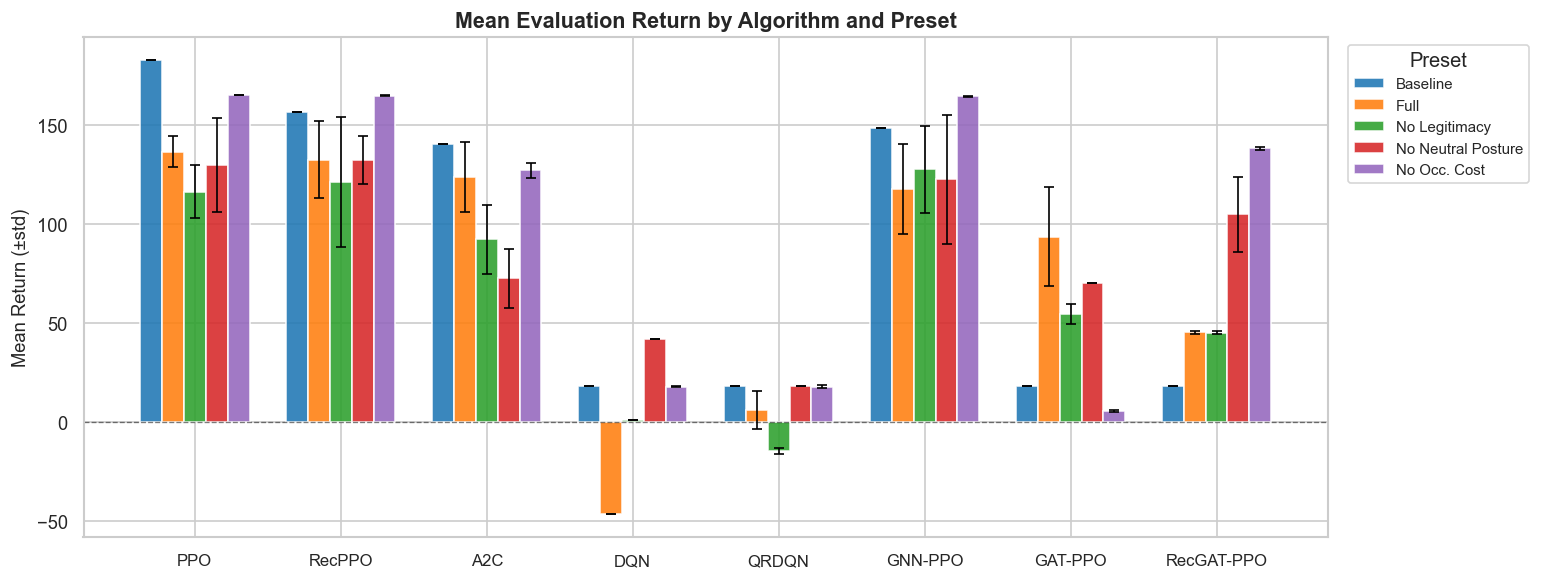

In [4]:
algo_order = [a for a in ALGO_ORDER if a in df["algorithm"].unique()]
preset_order = [p for p in PRESET_ORDER if p in df["preset"].unique()]
algo_labels = [ALGO_LABELS[a] for a in algo_order]
preset_labels = [PRESET_LABELS[p] for p in preset_order]

n_algos = len(algo_order)
n_presets = len(preset_order)
bar_width = 0.75 / n_presets
x = np.arange(n_algos)
offsets = np.linspace(-(n_presets - 1) / 2, (n_presets - 1) / 2, n_presets) * bar_width

fig, ax = plt.subplots(figsize=(13, 5))
colors = sns.color_palette("tab10", n_presets)

for i, (preset, label) in enumerate(zip(preset_order, preset_labels)):
    subset = df[df["preset"] == preset].set_index("algorithm")
    means = [subset.loc[a, "mean_return"] if a in subset.index else np.nan for a in algo_order]
    stds = [subset.loc[a, "return_std"] if a in subset.index else np.nan for a in algo_order]
    ax.bar(
        x + offsets[i], means, bar_width,
        label=label, color=colors[i],
        yerr=stds, capsize=3, error_kw={"elinewidth": 1},
        alpha=0.88,
    )

ax.set_xticks(x)
ax.set_xticklabels(algo_labels, fontsize=10)
ax.set_ylabel("Mean Return (±std)", fontsize=11)
ax.set_title("Mean Evaluation Return by Algorithm and Preset", fontsize=13, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.legend(title="Preset", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## Plot 2 — Return Heatmap: Algorithm × Preset

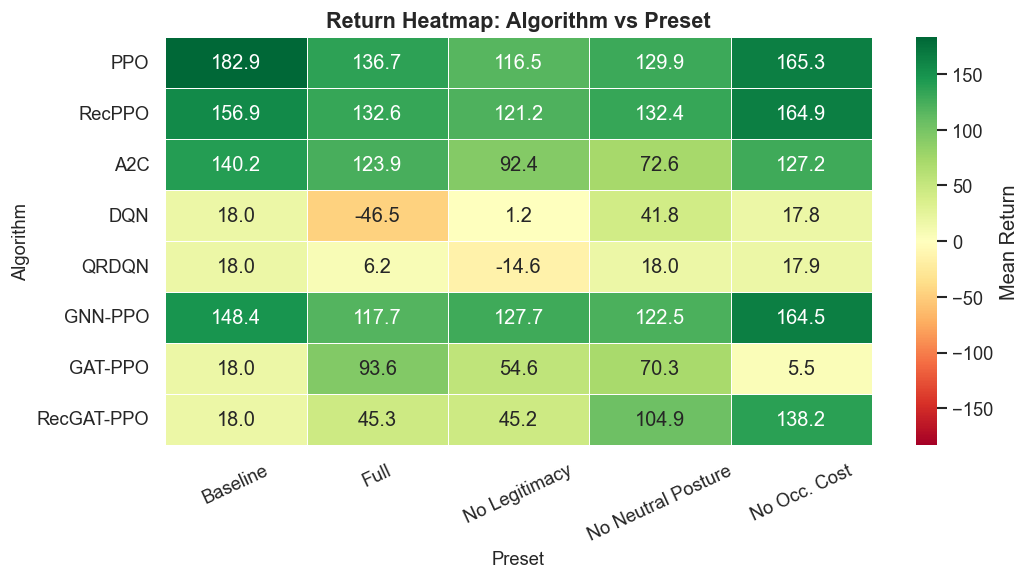

In [5]:
pivot = df.pivot(index="algorithm", columns="preset", values="mean_return")
pivot = pivot.reindex(index=algo_order, columns=preset_order)
pivot.index = [ALGO_LABELS[a] for a in pivot.index]
pivot.columns = [PRESET_LABELS[p] for p in pivot.columns]

vmax = pivot.abs().max().max()

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot, annot=True, fmt=".1f", linewidths=0.5,
    cmap="RdYlGn", center=0, vmin=-vmax, vmax=vmax,
    ax=ax, cbar_kws={"label": "Mean Return"},
)
ax.set_title("Return Heatmap: Algorithm vs Preset", fontsize=13, fontweight="bold")
ax.set_xlabel("Preset", fontsize=11)
ax.set_ylabel("Algorithm", fontsize=11)
ax.tick_params(axis="x", rotation=25)
ax.tick_params(axis="y", rotation=0)
fig.tight_layout()
plt.show()

## Plot 3 — Mean Episode Length by Algorithm and Preset

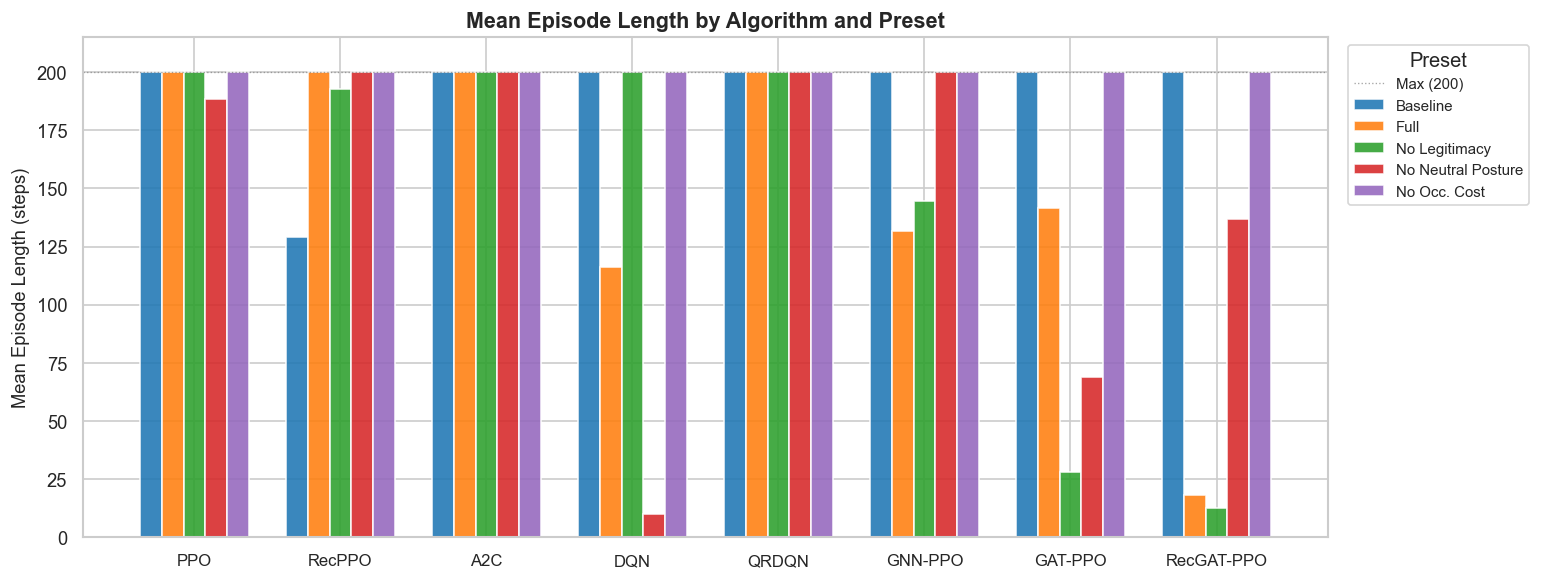

In [6]:
fig, ax = plt.subplots(figsize=(13, 5))

for i, (preset, label) in enumerate(zip(preset_order, preset_labels)):
    subset = df[df["preset"] == preset].set_index("algorithm")
    lengths = [subset.loc[a, "ep_len"] if a in subset.index else np.nan for a in algo_order]
    ax.bar(x + offsets[i], lengths, bar_width, label=label, color=colors[i], alpha=0.88)

ax.axhline(EPISODES_PER_EVAL * 4, color="gray", linewidth=0.8, linestyle=":", alpha=0.7, label="Max (200)")
ax.set_xticks(x)
ax.set_xticklabels(algo_labels, fontsize=10)
ax.set_ylabel("Mean Episode Length (steps)", fontsize=11)
ax.set_title("Mean Episode Length by Algorithm and Preset", fontsize=13, fontweight="bold")
ax.set_ylim(0, 215)
ax.legend(title="Preset", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## Plot 4 — Termination Reason Distribution by Algorithm (averaged across presets)

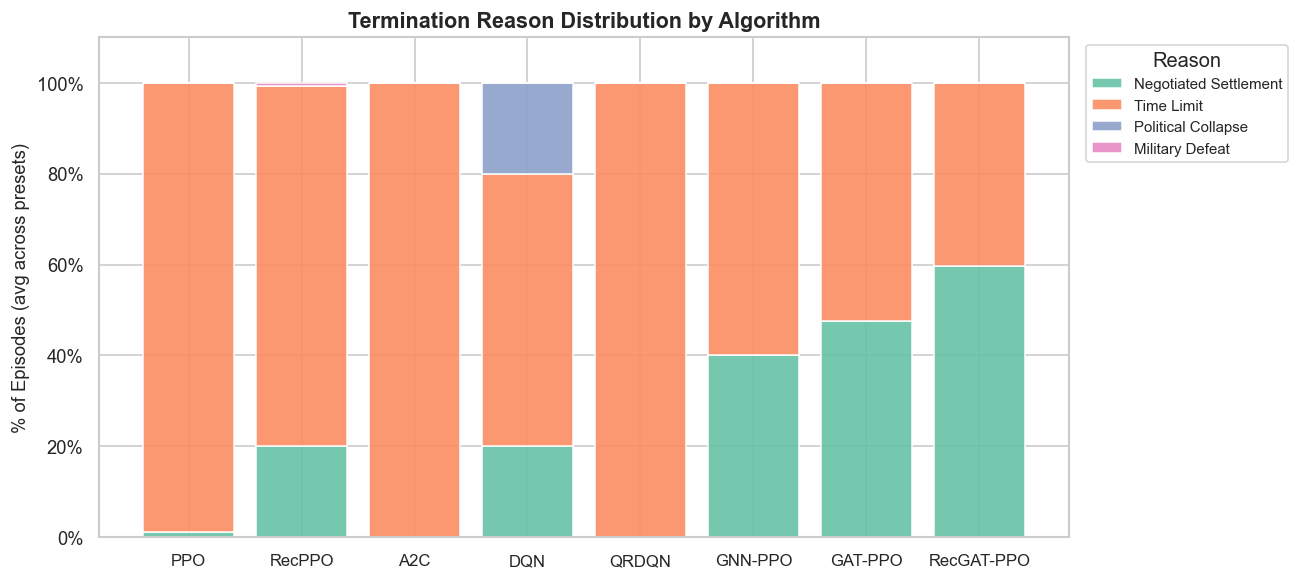

In [7]:
reason_pct = df.copy()
for col in REASON_COLS:
    reason_pct[col] = reason_pct[col] / EPISODES_PER_EVAL * 100

avg_reasons = (
    reason_pct.groupby("algorithm")[REASON_COLS]
    .mean()
    .reindex(algo_order)
)
avg_reasons.index = [ALGO_LABELS[a] for a in avg_reasons.index]

reason_colors = sns.color_palette("Set2", len(REASON_COLS))

fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(avg_reasons))
x_pos = np.arange(len(avg_reasons))

for col, color in zip(REASON_COLS, reason_colors):
    vals = avg_reasons[col].fillna(0).values
    ax.bar(x_pos, vals, bottom=bottom, label=REASON_LABELS[col], color=color, alpha=0.9)
    bottom += vals

ax.set_xticks(x_pos)
ax.set_xticklabels(avg_reasons.index, fontsize=10)
ax.set_ylabel("% of Episodes (avg across presets)", fontsize=11)
ax.set_title("Termination Reason Distribution by Algorithm", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title="Reason", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## Plot 5 — Win Rate (Negotiated Settlement) by Algorithm

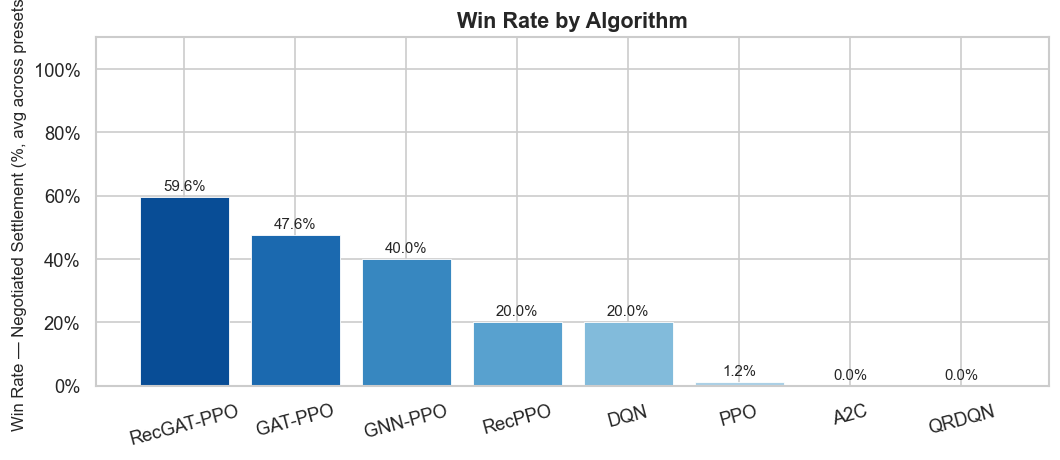

In [8]:
win_rate = (
    df.groupby("algorithm")["win_rate"]
    .mean()
    .reindex(algo_order)
    .reset_index()
)
win_rate["algo_label"] = win_rate["algorithm"].map(ALGO_LABELS)
win_rate = win_rate.sort_values("win_rate", ascending=False)

palette = sns.color_palette("Blues_r", len(win_rate))
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(win_rate["algo_label"], win_rate["win_rate"], color=palette, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, win_rate["win_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.2,
        f"{val:.1f}%",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_ylabel("Win Rate — Negotiated Settlement (%, avg across presets)", fontsize=10)
ax.set_title("Win Rate by Algorithm", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis="x", rotation=15)
fig.tight_layout()
plt.show()